# Coffee Bean Quality Prediction Project:
## Predictive Analytics of Coffee Bean Quality via Binary Classification
### Author: Shannon McFarland
### Last Modified: 3/2/24

<hr style="border:2px solid black">

## Introduction:

<font size="3"> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; One societal truth about the United States, is that the country runs on coffee. According the National Coffee Association, 63% of Americans drink more coffee than any other type of beverage, including water, each day. (National Coffee Association, 2023) To meet this caffeine demand for both the United States and worldwide, roughly 172 million bags of coffee are produced annually. Major coffee producers include Brazil, Columbia, Vietnam, and Indonesia. (USDA, 2023) With the vast quantity of coffee that is required to satisfy consumers, the quality of coffee beans produced is not always consistent. Factors that have been reported to affect coffee quality include coffee bean species (Arabica vs. Robusta), climatic growing conditions, soil quality, growing altitude, harvesting method (hand-picked vs. strip method), processing method (wet vs. dry), and storage conditions. (Deribe, 2019) 

<font size="3"> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; The variation in coffee quality led to the development of a standardized methodology known as cupping to rate batches of coffee beans. Cupping was created by the Specialty Coffee Association to ensure that coffee beans are being sold to importers and roasters at a price that matches their quality. The coffee is rated by professional coffee taste testers known as Q graders certified by the Coffee Quality Institute (CQI). (McCarthy, 2021) The grading involves evaluating not only bean appearance, but also the coffee itself post brewing. This includes rating the cup of coffee on flavor, aroma, sweetness, acidity, balance, and aftertaste. Overall, the coffee beans are then given a score between 0 and 100. Any coffee graded below 80 is considered lower quality and is typically used in commercial ground coffee. Coffee rated between 80 and 84.99 is considered “very good” specialty coffee while coffee rated between 85 to 89.99 is also considered specialty coffee, but at a premium/excellent level. If the coffee is rated between 90 to 100, it is awarded the very rare and expensive category of presidential award coffee. (McCarthy, 2021)

<font size="3"> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; The goal of this project is to create a model that helps coffee supplier buyers predict whether a specialty coffee being imported would likely be “premium/excellent” grade over “very good” based on the coffee’s species/variety and growing/processing conditions. A classifier model will be used be make this prediction. The model will be trained on a specialty coffee review dataset that was web scraped from the Coffee Quality Institute by James LaDoux. (LaDoux, 2018) Feature variables that will potentially be used to make predictions include altitude, species, variety, country of origin, and processing methods.

<hr style="border:2px solid black">

## Part 1: Exploratory Data Analysis (EDA)

In [4]:
# Import necessary libraries
import pandas as pd
import warnings
import matplotlib.pyplot as plt 
import seaborn as sns 

In [5]:
# Load coffee bean data set
coffee_df = pd.read_csv('coffee_bean_data.csv')
coffee_df

,Unnamed: 0,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,...,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,0,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,2,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,3,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,...,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,4,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1334,1334,Robusta,luis robles,Ecuador,robustasa,Lavado 1,our own lab,NaN,robustasa,NaN,...,Blue-Green,1,"January 18th, 2017",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,NaN,NaN,NaN
1335,1335,Robusta,luis robles,Ecuador,robustasa,Lavado 3,own laboratory,NaN,robustasa,40,...,Blue-Green,0,"January 18th, 2017",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,40.0,40.0,40.0
1336,1336,Robusta,james moore,United States,fazenda cazengo,NaN,cafe cazengo,NaN,global opportunity fund,795 meters,...,NaN,6,"December 23rd, 2015",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,795.0,795.0,795.0
1337,1337,Robusta,cafe politico,India,NaN,NaN,NaN,14-1118-2014-0087,cafe politico,NaN,...,Green,1,"August 25th, 2015",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,NaN,NaN,NaN


In [6]:
# Column names
coffee_df.columns

Index(['Unnamed: 0', 'Species', 'Owner', 'Country.of.Origin', 'Farm.Name',
       'Lot.Number', 'Mill', 'ICO.Number', 'Company', 'Altitude', 'Region',
       'Producer', 'Number.of.Bags', 'Bag.Weight', 'In.Country.Partner',
       'Harvest.Year', 'Grading.Date', 'Owner.1', 'Variety',
       'Processing.Method', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body',
       'Balance', 'Uniformity', 'Clean.Cup', 'Sweetness', 'Cupper.Points',
       'Total.Cup.Points', 'Moisture', 'Category.One.Defects', 'Quakers',
       'Color', 'Category.Two.Defects', 'Expiration', 'Certification.Body',
       'Certification.Address', 'Certification.Contact', 'unit_of_measurement',
       'altitude_low_meters', 'altitude_high_meters', 'altitude_mean_meters'],
      dtype='object')

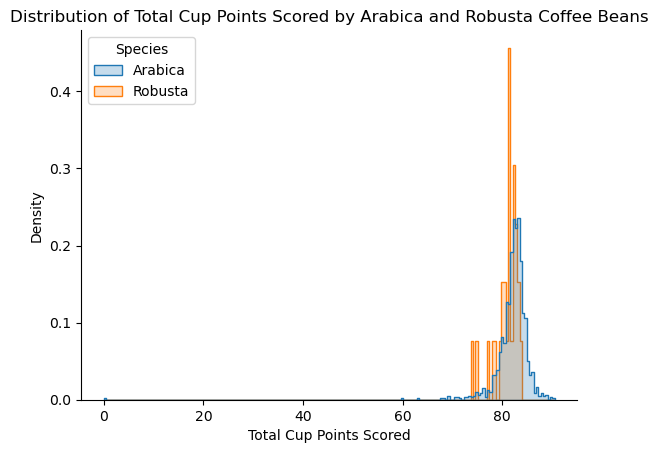

In [7]:
# Histogram graph showcasing the frequency of total cup points in the dataset, filtered for species

total_cup_histplot = sns.histplot(x = "Total.Cup.Points", data = coffee_df, hue = "Species",
                              element = "step", stat = "density", common_norm = False)
total_cup_histplot.set(xlabel = "Total Cup Points Scored",
            title = "Distribution of Total Cup Points Scored by Arabica and Robusta Coffee Beans")
sns.despine()
sns.move_legend(total_cup_histplot, "upper left")

<font size="3"> About 75% of coffee produced worldwide is the Arabica species while only 25% coffee grown is the Robusta species. (USDA, 2023) As a result, due to the larger representation of Arabica coffee reviews in the data set, the distribution of the above histogram was normalized into a density plot for more accurate comparison. 

<font size="3"> The above histogram shows the distribution of total cup points earned by the reviewed Arabica and Robusta coffees is skewed to the left. The total number of cup points a coffee can earn ranges from 0 - 100. Coffee bean production in its entirety may follow a normal distribution. However, since the data set is focused on specialty coffees, which are scored 80 and above, the distribution for this data set is skewed. 

<font size="3"> Arabica coffee has a more prominent, longer tail to the right compared to Robusta. This could indicate that Arabica is more frequently categorized as a higher end coffee. This inidication would align with the domain knowledge that robusta coffee beans are typically sold as lower quality, ground coffee versus higher quality, whole bean coffee.(McCarthy, 2021)

<font size="3"> There also appears to be a datapoint at zero. This may be a misentered, error datapoint since the majority of datapoints in the set are on the higher end of the total cup points range. This data point will investigated and possibly deleted during the data preparation phase of the project. 

In [9]:
# Preparation step to create a scatter plot using altitude
# As seen below, not all entered altitude measurements are in meters.
coffee_df["unit_of_measurement"].value_counts()

m     1157
ft     182
Name: unit_of_measurement, dtype: int64

In [10]:
# Function that converts any altitudes entered as feet into meters. 
# If-else statement identifies whether measurement is entered into "unit of measurement" column as feet or meters.
# If feet is listed then function will convert altitude measurement in altitude column into meters.
def convert_to_meters(row):
    measurement = row["altitude_mean_meters"]
    unit = row["unit_of_measurement"]
    
    if unit == "ft":
        return measurement * 0.3048 # feet to meters conversion
    else: 
        return measurement

# Applies meters conversion function to altitude column, if applicable.
coffee_df["altitude_mean_meters"] = coffee_df.apply(convert_to_meters, axis = 1) # Axis = 1 to apply to a column
    

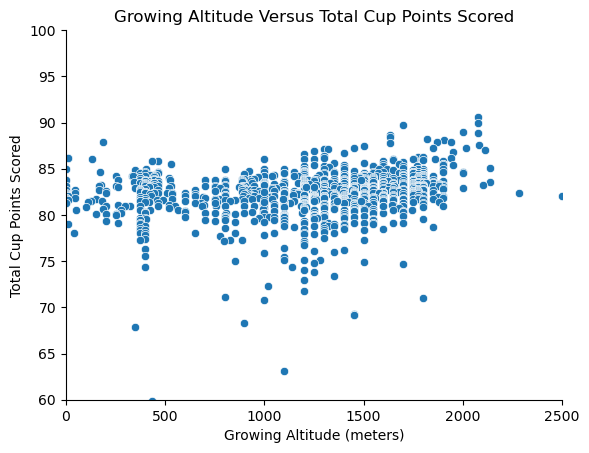

In [11]:
# Scatter plot showcasing relationship between altitude and total cup points
total_cup_scatterplot = sns.scatterplot(data = coffee_df, x = "altitude_mean_meters",  y = "Total.Cup.Points")
total_cup_scatterplot.set(xlabel = "Growing Altitude (meters)", ylabel = "Total Cup Points Scored",
            title = "Growing Altitude Versus Total Cup Points Scored")
total_cup_scatterplot.set_xlim(0, 2500)
total_cup_scatterplot.set_ylim(60, 100)
sns.despine()

<font size="3"> The above scatter plot demonstrates that the altitude the beans are grown does not have as strong of a relationship as reported to be on the overall quality of coffee or at least on beans grown specifically for specialty coffee. Overall, the quality of coffee appears to be constant with a slight positive slope as altitude increases. It is possible, that altitude may have more of a relationship of different types of flavors versus the overall quality score. 

<font size="3"> The above graph's axises were also adjusted since there were a couple of outliers with altitudes reported over 100,000 meters. All of these unseen datapoints have a total cup points score in the 80s range. These outliers will be investigated in the data preparation phase of the project. 

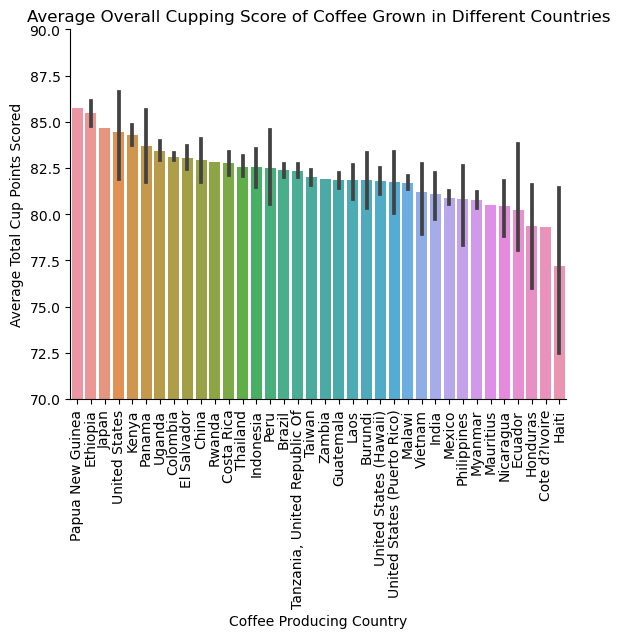

In [13]:
# Bar graph showcasing the average total cup points scored for different coffee bean producing countries 

country_barplot = sns.barplot(data = coffee_df, x = "Country.of.Origin", y = "Total.Cup.Points",
                                order = coffee_df.groupby('Country.of.Origin')['Total.Cup.Points'].agg('mean')
                              .sort_values(ascending=False).index)

country_barplot.set(xlabel = "Coffee Producing Country", ylabel = "Average Total Cup Points Scored",
            title = "Average Overall Cupping Score of Coffee Grown in Different Countries")

country_barplot.set_ylim(70, 90)
sns.despine()
plt.xticks(rotation = 90) # Rotates x axis labels to appear vertical
plt.show()

<font size="3"> The bar graph above demonstrates all coffee producing countries despite variation in climatic conditions have the ability to grown high quality, specialty coffee. This is seen as all the countries have at least some data points in the 80+ total cup points score range. Since the data set is focused on specialty coffee, the mean score for all the countries fall within a similar range of 80 to 85. Some countries appear to have a slightly higher mean score than others. For example, Ethiopia has a mean score that is above 85, which classifies specialty coffee as premium/excellent. However, there too much variability across the countries to determine if there is any significant difference between them. Additionally, some countries do not have any error bars present, indicating that they may have a sample size of 1. This will be investigated in the data preparation phase.  

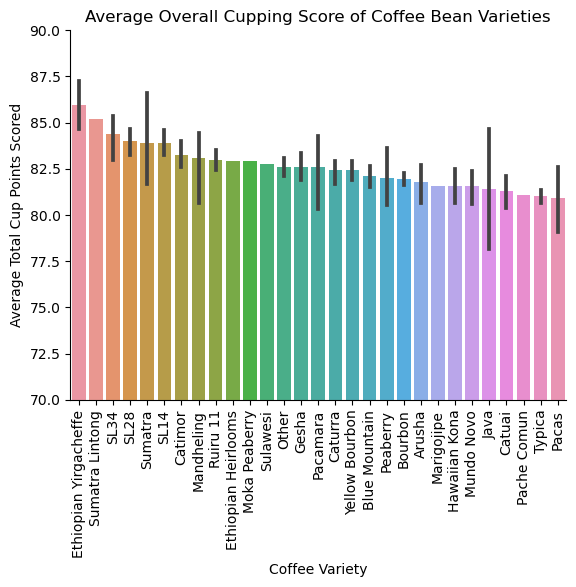

In [15]:
# Bar graph showcasing the average total cup points scored for different coffee bean varieties

variety_barplot = sns.barplot(data = coffee_df, x = "Variety", y = "Total.Cup.Points",
                                order = coffee_df.groupby('Variety')['Total.Cup.Points'].agg('mean').
                              sort_values(ascending=False).index)

variety_barplot.set(xlabel = "Coffee Variety", ylabel = "Average Total Cup Points Scored",
            title = "Average Overall Cupping Score of Coffee Bean Varieties")

variety_barplot.set_ylim(70, 90)
sns.despine()
plt.xticks(rotation = 90) # Rotates x axis labels to appear vertical
plt.show()

<font size="3">  Varieties for crops is similar to how breeds are for dogs. Crop varieties are bred for different characteristics such disease resistance, productivity, drought tolerance, product flavor, etc. Therefore, certain varities of crops could have a better product flavor profile than others. Since the data set is focused on specialty coffees, the varieties featured are probably all varieties that have been bred to have better flavor beans. This is seen as they all have a mean cupping score within the 80 to 87 range. However, this is hard to conclude untill there is another coffee data set with lower quality scores to compare to. Some coffee varieties have scored on average slightly higher than others. For example, the Ethiopian Yirgacheffe variety has a mean score above 85 into the premium coffee range. Additionally, some varieties do not have any error bars present, indicating that they may have a sample size of 1. This will be investigated in the data preparation phase.  

## Conclusion:

<font size="3"> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; From the graphical analysis, it was seen that there is not too much variation in total cup score within the variables such as altitude and coffee variety. Therefore, any model built going forward may not account for a lot of the variation seen in the total cupping score and have a low accuracy predicting whether the coffee would be graded as "premium/excellent". A step going forward post this project would be adding other variables in the growing, harvesting, and processing conditions that could have a relationship with total cup score and improve the model's accuracy. Additionally, expanding the data pool size to include some lower quality coffee samples may be beneficial in further understanding the relationship between the feature variables and cupping score. 
    
<font size="3"> It was additionally learned from the graphical analysis that there are some outliers in the altitude and total cup points columns that should be addressed during the data preparation phase. 

## References:

Deribe, H. (2019). Review on Factors which Affect Coffee (Coffea Arabica L.) Quality in South Western, Ethiopia. International Journal of Forestry and 

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; Horticulture (IJFH), 5(1), 12–19. https://doi.org/http://dx.doi.org/10.20431/2454-9487.0501003 www.arcjournals.org.

LaDoux, J. (2018) Coffee Quality database from CQI. [Data Set]. 

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; https://www.kaggle.com/datasets/volpatto/coffee-quality-database-from-cqi?select=merged_data_cleaned.csv.

McCarthy, J. (2021, November 2). Cupping & Scoring: Speciality Coffees. Cru Kafe. https://www.crukafe.com/en-us/blogs/news/cupping-scoring. 

National Coffee Association. (2023, September 19). Celebrate National Coffee Day with latest data on America’s favorite beverage. NCA.

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; https://www.ncausa.org/Newsroom/Celebrate-National-Coffee-Day-with-latest-data-on-Americas-favorite-beverage. 

USDA. (2023). (rep.). Coffee: World Markets and Trade. United States Department of Agriculture Foreign Agricultural Service. Retrieved from 

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; https://downloads.usda.library.cornell.edu/usda-esmis/files/m900nt40f/wd377g27h/bk129x03v/coffee.pdf. 

<hr style="border:2px solid black">

# Part 2: Data Preparation

The goal of this step is to end with a simplified, cleaned up data set that is ready for building/training/evaluating a classification model. The finalized data set will contain only the feature variables of "Species", "Variety", "Country of Origin", "Altitude", "Processing Method", "Quakers", and binary target variable representing whether the coffee is graded "premium/excellent". Cleaning steps will include handling missing values, addressing any outliers, and replacing any of the categorical variables with dummy variables.

## Step 1: Create a New Subset Dataframe With Only Features Related to Model

The original coffee data set cotained a total of 44 columns. In an effort to create a more simplified number of feature variables to run the model, the number of columns in the data set was reduced to seven (six feature variables and one target). These variables were selected becasue they are all related the growing, harvesting, and processing of the coffee beans. These are all steps that occur before the beans are evaluated for quality. 

The original data set does include variables such as coffee bean flavor, acidity, aroma, and aftertaste. While interesting, these variables were dropped because their values directly contribute to the total cup points target variable and would cause multicollinearity in the model. Additional variables that were dropped included identification variables such as lot number, owner, farm name, and company. These variables were all dropped since they are very specific and some only have a representation of one in the data set. 

In [21]:
# Creation of subset dataframe with feature and target variables related to the model
coffee2_df = coffee_df[["Species", "Variety", "Country.of.Origin", "altitude_mean_meters", "Processing.Method", 
                        "Quakers", "Total.Cup.Points"]]
coffee2_df

,Species,Variety,Country.of.Origin,altitude_mean_meters,Processing.Method,Quakers,Total.Cup.Points
0,Arabica,NaN,Ethiopia,2075.0,Washed / Wet,0.0,90.58
1,Arabica,Other,Ethiopia,2075.0,Washed / Wet,0.0,89.92
2,Arabica,Bourbon,Guatemala,1700.0,NaN,0.0,89.75
3,Arabica,NaN,Ethiopia,2000.0,Natural / Dry,0.0,89.00
4,Arabica,Other,Ethiopia,2075.0,Washed / Wet,0.0,88.83
...,...,...,...,...,...,...,...
1334,Robusta,NaN,Ecuador,NaN,NaN,0.0,78.75
1335,Robusta,NaN,Ecuador,40.0,NaN,0.0,78.08
1336,Robusta,NaN,United States,795.0,Natural / Dry,0.0,77.17
1337,Robusta,NaN,India,NaN,Natural / Dry,0.0,75.08


## Step 2: Handle Missing Data

To address any missing values in the data set, I first determined the count of missing values in each column. I then worked from column to column addressing each of their missing values. As seen below, 5 out of the 7 columns had at least one missing value to be deal with. I used the data type (numerical vs. categorical) and my domain knowledge to help decide how to handle each column's missing values.

In [23]:
# Determine how many missing values are in each column
coffee2_df.isna().sum()

Species                   0
Variety                 226
Country.of.Origin         1
altitude_mean_meters    230
Processing.Method       170
Quakers                   1
Total.Cup.Points          0
dtype: int64

### Step 2a: Delete Any Row Missing Greater than 50% of Their Data

Before going to each column individually to deal with their missing values, I first checked to see if there any rows that could automatically be deleted for having too many missing values. I set the dropna() function to delete any rows that were missing more than 3 out of 7 values. In using this method, one row was deleted. 

In [25]:
# Set to keep rows that have at least 4 out of 7 non-NaN values 
# Number of missing values reduced
coffee2_df = coffee2_df.dropna(axis = 0, thresh = 4) # Axis set to 0 for rows
coffee2_df.isna().sum()

Species                   0
Variety                 225
Country.of.Origin         0
altitude_mean_meters    229
Processing.Method       169
Quakers                   1
Total.Cup.Points          0
dtype: int64

### Step 2b: Address Missing Values in Quaker Column

The Quaker column only had one missing value. Therefore, I first pulled up the row with the missing quaker value individually, to see if there was anything else weird in the row. Since it seemed fine, I choose to replace the missing value with the column's mode of zero. Quakers are unripe coffee beans that get mixed in with ripened beans during harvest. Quakers usually get mixed in with ripened beans when a faster, machine based method is used for harvesting versus the slower, handpicking method. Since the data set is focused on specialty coffee, the majority of entries have a zero in Quaker column.

In [27]:
# Quaker column has one missing value
# Check row that has Quaker missing value
coffee2_df[coffee2_df["Quakers"].isnull()]

,Species,Variety,Country.of.Origin,altitude_mean_meters,Processing.Method,Quakers,Total.Cup.Points
366,Arabica,Caturra,Colombia,1750.0,Washed / Wet,NaN,83.5


In [28]:
# Using row index, replace individual missing value with column's mode of 0
coffee2_df.loc[366, "Quakers"] = 0

coffee2_df.isna().sum() # Missing values in Quaker column reduced to zero

Species                   0
Variety                 225
Country.of.Origin         0
altitude_mean_meters    229
Processing.Method       169
Quakers                   0
Total.Cup.Points          0
dtype: int64

### Step 2c: Address Missing Values in Variety Column

The Variety, Altitude, and Processing Method columns had about a third of their values missing. Since this a large chunk of data, the missing values were filled rather than deleting their entire row.

I choose to address the missing values in the Variety column by first looking at the Species column. The data set contains two coffee species: Arabica and Robusta. The majority of Robusta entries had a missing value in the Variety column. Therefore, I decided to assign all Robusta species with a generic "Robusta" variety.

In [30]:
# Display unique values in the variety column for entries of the Robusta species 
coffee2_df2 = coffee2_df[coffee2_df["Species"] == "Robusta"] # Filter data set with only Robusta entries 
print(coffee2_df2["Variety"].unique()) # Unique values in variety column for Robusta entries 
print(coffee2_df2["Variety"].value_counts()) # Unique value counts; does not count NaNs

[nan 'Other' 'Arusha']
Other     2
Arusha    1
Name: Variety, dtype: int64


In [31]:
# Variety values for Robusta species are replaced with "generic Robusta" variety
coffee2_df.loc[coffee2_df["Species"] == "Robusta", "Variety"] = "Robusta"
coffee2_df[coffee2_df["Species"] == "Robusta"].head()

,Species,Variety,Country.of.Origin,altitude_mean_meters,Processing.Method,Quakers,Total.Cup.Points
1311,Robusta,Robusta,Uganda,1488.0,NaN,0.0,83.75
1312,Robusta,Robusta,India,3170.0,Washed / Wet,0.0,83.50
1313,Robusta,Robusta,India,1000.0,NaN,0.0,83.25
1314,Robusta,Robusta,Uganda,1212.0,NaN,0.0,83.00
1315,Robusta,Robusta,Uganda,1250.0,NaN,0.0,83.00


In [32]:
coffee2_df.isna().sum() # Number of missing values in Variety column reduced

Species                   0
Variety                 200
Country.of.Origin         0
altitude_mean_meters    229
Processing.Method       169
Quakers                   0
Total.Cup.Points          0
dtype: int64

### Step 2d: Missing Value Detour (Address Countries and Varieties with Low Value Counts)

The remaining Variety entries with missing values are all of the Arabica species. Using my domain knowledge of crop selection, I know crop varieties are choosen not only for their productivity, but also how well they grow in a specific environment. Specific varieties have been bred to grow better in rainy vs. dry and hot vs. cold conditions, as well as, have an increased tolerance to regional diseases. Since the Country of Origin column does not have any missing values, I chose to use the mode variety for each country to help fill in the missing values in the variety column. 

However, some of the countries only have a count of one in the data set, as seen below. Having a training data set containing lot of countries with low representation could negative impact the model's accuracy. Therefore, I decided to combine some of the countries with low representation based on region as they would have similar climatic growing conditions.

Similar to the country column, the Variety column also had values with low representation. Since varieties are bred to grow in specific climatic conditions, I chose to combine the varieties with lower representation based on the region they originate from. I decided this method would be more useful for the model rather than lumping all the low count varieties together or deleting their rows entirely. 

In [34]:
coffee2_df["Country.of.Origin"].value_counts() # Count of unique values in the Country column

Mexico                          236
Colombia                        183
Guatemala                       181
Brazil                          132
Taiwan                           75
United States (Hawaii)           73
Honduras                         53
Costa Rica                       51
Ethiopia                         44
Tanzania, United Republic Of     40
Uganda                           36
Thailand                         32
Nicaragua                        26
Kenya                            25
El Salvador                      21
Indonesia                        20
China                            16
India                            14
Malawi                           11
United States                    10
Peru                             10
Myanmar                           8
Vietnam                           8
Haiti                             6
Philippines                       5
United States (Puerto Rico)       4
Panama                            4
Ecuador                     

In [35]:
# Combine countries with smaller representation into more general regions
# Chose to combine any country with a sample size < 10 
Africa_strings = ["Cote d?Ivoire", "Mauritius", "Zambia", "Rwanda", "Burundi"]
Southeast_Asia_strings = ["Japan", "Papua New Guinea", "Laos", "Philippines", "Vietnam", "Myanmar"]
Carribbean_strings = ["United States (Puerto Rico)", "Haiti"]
Americas_strings = ["Ecuador", "Panama", "Peru"]

# Replace function replaces specific country names with broader regional name using the lists above
coffee3_df = coffee2_df.replace(Africa_strings, "Other African Countries")
coffee3_df = coffee3_df.replace(Southeast_Asia_strings, "Southeast Asia")
coffee3_df = coffee3_df.replace(Carribbean_strings, "Carribbean")
coffee3_df = coffee3_df.replace(Americas_strings, "Other Central/South America Countries")

coffee3_df["Country.of.Origin"].value_counts() # Reduced number of unique values in Country column

Mexico                                   236
Colombia                                 183
Guatemala                                181
Brazil                                   132
Taiwan                                    75
United States (Hawaii)                    73
Honduras                                  53
Costa Rica                                51
Ethiopia                                  44
Tanzania, United Republic Of              40
Uganda                                    36
Thailand                                  32
Nicaragua                                 26
Southeast Asia                            26
Kenya                                     25
El Salvador                               21
Indonesia                                 20
Other Central/South America Countries     17
China                                     16
India                                     14
Malawi                                    11
United States                             10
Carribbean

In [36]:
coffee3_df["Variety"].value_counts() # Count of unique values in the Variety column

Caturra                  256
Bourbon                  226
Typica                   211
Other                    108
Catuai                    74
Hawaiian Kona             44
Yellow Bourbon            35
Mundo Novo                33
Robusta                   28
Catimor                   20
SL14                      17
SL28                      15
Pacas                     13
Gesha                     12
SL34                       8
Pacamara                   8
Peaberry                   5
Arusha                     5
Sumatra                    3
Mandheling                 3
Ethiopian Yirgacheffe      2
Java                       2
Ruiru 11                   2
Blue Mountain              2
Ethiopian Heirlooms        1
Moka Peaberry              1
Sulawesi                   1
Marigojipe                 1
Pache Comun                1
Sumatra Lintong            1
Name: Variety, dtype: int64

In [37]:
# Combine varieties with smaller representation into broader groups based on origin region
# Chose to combine any varieties with a sample size < 10 

Africa_beans = ["Ethiopian Heirlooms", "Ethiopian Yirgacheffe", "Ruiru 11", "Moka Peaberry", "Peaberry", 
                "Arusha", "SL34"]
Southeast_Asia_beans = ["Sumatra Lintong", "Sulawesi", "Java", "Sumatra"]
Americas_beans = ["Pache Comun", "Marigojipe", "Mandheling", "Pacamara", "Blue Mountain"]

# Replace function replaces specific variety names with broader regional group name using the lists above
coffee3_df = coffee3_df.replace(Africa_beans, "Africa Varieties")
coffee3_df = coffee3_df.replace(Southeast_Asia_beans, "Southeast Asia Varieties")
coffee3_df = coffee3_df.replace(Americas_beans, "Americas Varieties")

coffee3_df["Variety"].value_counts() # Reduced number of unique values in Country column

Caturra                     256
Bourbon                     226
Typica                      211
Other                       108
Catuai                       74
Hawaiian Kona                44
Yellow Bourbon               35
Mundo Novo                   33
Robusta                      28
Africa Varieties             24
Catimor                      20
SL14                         17
SL28                         15
Americas Varieties           15
Pacas                        13
Gesha                        12
Southeast Asia Varieties      7
Name: Variety, dtype: int64

### Step 2e: Address Missing Values in Variety Column (Part II)

After reducing the number of unique values in the Country of Origin and Variety columns, I used the mode variety of each country to help fill any missing variety values. 

In [39]:
# Replaces missing values in Variety column with its country's mode value
coffee3_df['Variety'] = coffee3_df.groupby('Country.of.Origin')['Variety'].transform(lambda x: x.fillna(x.mode()[0]))

coffee3_df["Variety"].value_counts() # Updated count of Varieties after using mode to fill NaNs

Caturra                     344
Bourbon                     258
Typica                      223
Other                       142
Catuai                       74
Hawaiian Kona                71
Yellow Bourbon               35
Mundo Novo                   33
Robusta                      29
Africa Varieties             24
Catimor                      20
SL14                         18
SL28                         17
Americas Varieties           15
Pacas                        13
Gesha                        12
Southeast Asia Varieties     10
Name: Variety, dtype: int64

In [40]:
coffee3_df.isna().sum() # Number of missing values in Variety column reduced to zero

Species                   0
Variety                   0
Country.of.Origin         0
altitude_mean_meters    229
Processing.Method       169
Quakers                   0
Total.Cup.Points          0
dtype: int64

### Step 2f: Address Missing Values in Processing Method Column

Similar to the Variety column, I used the mode processing method value for each country to replace any missing values in Processing Method column. There are four main categories of processing method for the coffee beans: Washed/Wet, Natural/Dry, Pulped natural/honey, Semi-washed/Semi-pulped. The Processing Method used is usually based on the environment and the availability of water.

In [42]:
coffee3_df["Processing.Method"].unique() # List of unique values in Processing Method column

array(['Washed / Wet', nan, 'Natural / Dry', 'Pulped natural / honey',
       'Semi-washed / Semi-pulped', 'Other'], dtype=object)

In [43]:
# Replaces missing values in Processing Method column with its country's mode value
coffee3_df['Processing.Method'] = coffee3_df.groupby(
    'Country.of.Origin')['Processing.Method'].transform(lambda x: x.fillna(x.mode()[0]))

coffee3_df.isna().sum() # Number of missing values in Processing Method column reduced to zero

Species                   0
Variety                   0
Country.of.Origin         0
altitude_mean_meters    229
Processing.Method         0
Quakers                   0
Total.Cup.Points          0
dtype: int64

### Step 2g: Address Missing Values in Altitude Column

For filling in any missing values in the Altitude column, I decided to use the country's median altitude. During the EDA portion of the project, it was discovered that the Altitude column does have outliers. Therefore, I decided to use the country's median value versus the mean, since the median is less susceptible to extreme values.

In [45]:
# Replaces missing values in altitude column with its country's median value
coffee3_df['altitude_mean_meters'] = coffee3_df.groupby(
    'Country.of.Origin')['altitude_mean_meters'].transform(lambda x: x.fillna(x.median()))

coffee3_df.isna().sum() # Number of missing values in Altitude column reduced to zero

Species                 0
Variety                 0
Country.of.Origin       0
altitude_mean_meters    0
Processing.Method       0
Quakers                 0
Total.Cup.Points        0
dtype: int64

## Step 3: Handle Outliers

### Step 3a: Address Outliers in Total Cup Points Column

During EDA portion of Milestone 1, it was discovered that the Total Cup Points column had an outlier of zero. Upon further investigation, it appears the zero was a misentering error since its closest value in the data set is 59.83. I decided to replace the zero with the median value of samples that have the same conditions as the erroneous value.

In [47]:
# Locate Total Cup Points outlier with error value of zero
coffee3_df[(coffee3_df["Total.Cup.Points"] < 60)]

,Species,Variety,Country.of.Origin,altitude_mean_meters,Processing.Method,Quakers,Total.Cup.Points
1309,Arabica,Catuai,Guatemala,431.999136,Washed / Wet,0.0,59.83
1310,Arabica,Caturra,Honduras,1400.000000,Washed / Wet,0.0,0.00


In [48]:
# Create subset dataframe that has the same conditions as the erroneous row
filtered_df = coffee3_df[(coffee3_df["Variety"] == "Caturra") & (coffee3_df["Country.of.Origin"] == "Honduras") 
           & (coffee3_df["altitude_mean_meters"] == 1400) & (coffee3_df["Processing.Method"] == "Washed / Wet")]

filtered_df

,Species,Variety,Country.of.Origin,altitude_mean_meters,Processing.Method,Quakers,Total.Cup.Points
28,Arabica,Caturra,Honduras,1400.0,Washed / Wet,0.0,86.67
316,Arabica,Caturra,Honduras,1400.0,Washed / Wet,0.0,83.67
655,Arabica,Caturra,Honduras,1400.0,Washed / Wet,0.0,82.50
690,Arabica,Caturra,Honduras,1400.0,Washed / Wet,0.0,82.42
804,Arabica,Caturra,Honduras,1400.0,Washed / Wet,0.0,82.00
817,Arabica,Caturra,Honduras,1400.0,Washed / Wet,0.0,81.92
824,Arabica,Caturra,Honduras,1400.0,Washed / Wet,0.0,81.92
912,Arabica,Caturra,Honduras,1400.0,Washed / Wet,0.0,81.50
1064,Arabica,Caturra,Honduras,1400.0,Washed / Wet,0.0,80.58
1310,Arabica,Caturra,Honduras,1400.0,Washed / Wet,0.0,0.00


In [49]:
coffee3_df.loc[[1310], "Total.Cup.Points"] = filtered_df["Total.Cup.Points"].median() # Replace error with median

coffee3_df.loc[[1310]] # Print outlier row with updated Total.Cup.Points value

,Species,Variety,Country.of.Origin,altitude_mean_meters,Processing.Method,Quakers,Total.Cup.Points
1310,Arabica,Caturra,Honduras,1400.0,Washed / Wet,0.0,81.96


### Step 3b: Address Extreme Outliers in Altitude column

During the EDA portion of Milestone 1, it was also discovered that the altitude column had a good amount of outliers. However, the column did have four outliers with extreme values. As seen below, there is one value for Brazil that is 11,000 meters, two values for Guatemala that are 190,164 meters, and one value for Nicaragua that is 110,000 meters. All of these values are above the actual highest point in each of their respective countries. Therefore, these values are most likely a misentering error. I decided to replace each of these values with their country's median altitude. 

In [51]:
# Majority of samples have an altitude below 2500 meters
# Filtered data set showing potential outliers in the altitude column
coffee3_df[(coffee3_df["altitude_mean_meters"] > 2500)]

,Species,Variety,Country.of.Origin,altitude_mean_meters,Processing.Method,Quakers,Total.Cup.Points
89,Arabica,Caturra,Colombia,2560.0,Natural / Dry,0.0,85.08
193,Arabica,Caturra,Colombia,2560.0,Natural / Dry,0.0,84.25
215,Arabica,Bourbon,Guatemala,3280.0,Washed / Wet,0.0,84.17
274,Arabica,Caturra,Colombia,2527.0,Washed / Wet,0.0,83.83
543,Arabica,Africa Varieties,Brazil,11000.0,Semi-washed / Semi-pulped,0.0,82.92
628,Arabica,Caturra,Colombia,3850.0,Washed / Wet,0.0,82.67
837,Arabica,Bourbon,Guatemala,3280.0,Washed / Wet,0.0,81.83
840,Arabica,Catuai,Southeast Asia,4001.0,Washed / Wet,0.0,81.83
896,Arabica,Bourbon,Guatemala,190164.0,Washed / Wet,0.0,81.58
1001,Arabica,Bourbon,Guatemala,3280.0,Washed / Wet,0.0,81.00


In [52]:
# Replace each of the four extreme altitude values with their respective country's median altitude
coffee3_df.loc[[543], "altitude_mean_meters"] = coffee3_df.loc[coffee3_df['Country.of.Origin'] == 
                                                               'Brazil', 'altitude_mean_meters'].median()

coffee3_df.loc[[896, 1144], "altitude_mean_meters"] = coffee3_df.loc[coffee3_df['Country.of.Origin'] == 
                                                               'Guatemala', 'altitude_mean_meters'].median()

coffee3_df.loc[[1040], "altitude_mean_meters"] = coffee3_df.loc[coffee3_df['Country.of.Origin'] == 
                                                               'Nicaragua', 'altitude_mean_meters'].median()

In [53]:
coffee3_df.loc[[543, 896, 1040, 1144]] # Extreme outlier rows with their updated median altitude values

,Species,Variety,Country.of.Origin,altitude_mean_meters,Processing.Method,Quakers,Total.Cup.Points
543,Arabica,Africa Varieties,Brazil,1000.000000,Semi-washed / Semi-pulped,0.0,82.92
896,Arabica,Bourbon,Guatemala,448.257168,Washed / Wet,0.0,81.58
1040,Arabica,Other,Nicaragua,1100.000000,Washed / Wet,0.0,80.75
1144,Arabica,Bourbon,Guatemala,448.257168,Washed / Wet,4.0,79.75


### Step 3c: Address Less Extreme Outliers in Altitude Column

After replacing the extreme values in the altitude column, the altitude column still had some less extreme outliers that needed to be addressed. The majority of the samples in the data set fall below 2500 meters with 75% of the samples being below 1600 meters. Using a function to identify outliers in a data set, 14 samples were recognized as outliers with a range between 3000 to 4287 meters. Since these are genuine values, rather than deleting them I decided mininmize the outliers' effects by transformating the column to a logarithmic scale. 

In [55]:
coffee3_df["altitude_mean_meters"].describe() # Descriptive statistics of the Altitude column

count    1338.000000
mean     1174.813431
std       583.642301
min         1.000000
25%       800.000000
50%      1250.000000
75%      1600.000000
max      4287.000000
Name: altitude_mean_meters, dtype: float64

In [56]:
# Function identifies outliers based on the Inter Quartile Range (IQR)
def find_outliers_IQR(df):
   q1 = df.quantile(0.25) # 1st quartile
   q3 = df.quantile(0.75) # 3rd quartile
   IQR = q3 - q1 # Distance between 1st and 3rd quartiles
   outliers = df[((df<(q1-1.5*IQR)) | (df>(q3+1.5*IQR)))] # Identifies outliers
   return outliers

outliers = find_outliers_IQR(coffee3_df["altitude_mean_meters"])
print("Number of Outliers: "+ str(len(outliers)))
print("Max Outlier Value: "+ str(outliers.max()))
print("Min Outlier Value: "+ str(outliers.min()))
outliers

Number of Outliers: 14
Max Outlier Value: 4287.0
Min Outlier Value: 3000.0


215     3280.0
628     3850.0
837     3280.0
840     4001.0
1001    3280.0
1038    3825.0
1073    3800.0
1098    4287.0
1123    3845.0
1269    3500.0
1312    3170.0
1316    3000.0
1318    3140.0
1333    3000.0
Name: altitude_mean_meters, dtype: float64

In [57]:
# Transform altitude to log scale to minimize outlier effects
import numpy as np
coffee3_df["log_altitude"] = [np.log(x) for x in coffee3_df["altitude_mean_meters"]]
coffee4_df = coffee3_df.drop("altitude_mean_meters", axis = 1) # Drop original altitude column 
coffee4_df.head()

,Species,Variety,Country.of.Origin,Processing.Method,Quakers,Total.Cup.Points,log_altitude
0,Arabica,Other,Ethiopia,Washed / Wet,0.0,90.58,7.637716
1,Arabica,Other,Ethiopia,Washed / Wet,0.0,89.92,7.637716
2,Arabica,Bourbon,Guatemala,Washed / Wet,0.0,89.75,7.438384
3,Arabica,Other,Ethiopia,Natural / Dry,0.0,89.00,7.600902
4,Arabica,Other,Ethiopia,Washed / Wet,0.0,88.83,7.637716


## Step 4: Create New Target Variable for Classifier Model

The goal of this project is to create a model that predicts whether or not the specialty coffee is "premium/excellent" grade based on its preprocessing factors. In order to run a classifier model the target must be binary. Since the Total Cup Points column is numerical, I converted the column into a new boolean column. In this new column, if the sample's Total Cup Points score is greater than or equal to 85 then the sample is assigned a 1 for "premium" grade. In contrast, if the sample's Total Cup Points score is less than 85 then the sample is assigned a 0 for not scoring high enough to be "premium". 

In [59]:
# Creates boolean column where if the Total Cups Points is >= 85, sample is assigned TRUE while < 85 is FALSE
coffee4_df["Premium"] = coffee4_df["Total.Cup.Points"] >= 85 
coffee4_df["Premium"] = coffee4_df["Premium"].astype(int) # Converts True/False to numbers 1/0
coffee4_df

,Species,Variety,Country.of.Origin,Processing.Method,Quakers,Total.Cup.Points,log_altitude,Premium
0,Arabica,Other,Ethiopia,Washed / Wet,0.0,90.58,7.637716,1
1,Arabica,Other,Ethiopia,Washed / Wet,0.0,89.92,7.637716,1
2,Arabica,Bourbon,Guatemala,Washed / Wet,0.0,89.75,7.438384,1
3,Arabica,Other,Ethiopia,Natural / Dry,0.0,89.00,7.600902,1
4,Arabica,Other,Ethiopia,Washed / Wet,0.0,88.83,7.637716,1
...,...,...,...,...,...,...,...,...
1334,Robusta,Robusta,Other Central/South America Countries,Washed / Wet,0.0,78.75,7.170120,0
1335,Robusta,Robusta,Other Central/South America Countries,Washed / Wet,0.0,78.08,3.688879,0
1336,Robusta,Robusta,United States,Natural / Dry,0.0,77.17,6.678342,0
1337,Robusta,Robusta,India,Natural / Dry,0.0,75.08,6.907755,0


In [60]:
coffee4_df = coffee4_df.drop("Total.Cup.Points", axis = 1) # Drop original altitude column 

## Step 5: Create Dummy Variables

In order to run the classifier model, all of the categorical variables had to be converted into dummy variables. Columns that were converted into dummy variables include Species, Variety, Country of Origin, and Processing Method. The new dummy variable dataframe was combined with Quakers, Log_altitude, and Premium to create one finalized, clean data set, ready for modeling. This data set contains 50 feature variable columns and one target variable column with a total of 1338 samples. 

In [62]:
# Create dummy variables for all categorical variables in coffee data set
cat_dummies = pd.get_dummies(coffee4_df[["Species", "Variety", "Country.of.Origin", "Processing.Method"]])
cat_dummies

,Species_Arabica,Species_Robusta,Variety_Africa Varieties,Variety_Americas Varieties,Variety_Bourbon,Variety_Catimor,Variety_Catuai,Variety_Caturra,Variety_Gesha,Variety_Hawaiian Kona,...,"Country.of.Origin_Tanzania, United Republic Of",Country.of.Origin_Thailand,Country.of.Origin_Uganda,Country.of.Origin_United States,Country.of.Origin_United States (Hawaii),Processing.Method_Natural / Dry,Processing.Method_Other,Processing.Method_Pulped natural / honey,Processing.Method_Semi-washed / Semi-pulped,Processing.Method_Washed / Wet
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1334,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1335,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1336,0,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
1337,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [63]:
clean_coffee = coffee4_df[["Premium", "Quakers", "log_altitude"]] # Add cleaned numerical columns to new dataframe
clean_coffee = pd.concat([clean_coffee, cat_dummies], axis = 1) # Combine numerical columns w/ dummies dataset
clean_coffee.head() # Finalized, cleaned up data set ready for modeling

,Premium,Quakers,log_altitude,Species_Arabica,Species_Robusta,Variety_Africa Varieties,Variety_Americas Varieties,Variety_Bourbon,Variety_Catimor,Variety_Catuai,...,"Country.of.Origin_Tanzania, United Republic Of",Country.of.Origin_Thailand,Country.of.Origin_Uganda,Country.of.Origin_United States,Country.of.Origin_United States (Hawaii),Processing.Method_Natural / Dry,Processing.Method_Other,Processing.Method_Pulped natural / honey,Processing.Method_Semi-washed / Semi-pulped,Processing.Method_Washed / Wet
0,1,0.0,7.637716,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,0.0,7.637716,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1,0.0,7.438384,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0.0,7.600902,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1,0.0,7.637716,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


<hr style="border:2px solid black">

# Part 3: Model Building and Evaluation

The goal of this step to select, train, and evaluate a classifier model that will predict whether the specialty coffee beans would be rated as "premium" grade based on preprocessing factors. Since the model selected is a classifier model, it will be evaluated using accuracy, precision score, recall score, F1 score, a confusion matrix and ROC curve. The optimal classifier model for the data will be determined using a grid search with 5-fold cross validation.

## Step 1: Split Data into Training and Testing Sets with "Premium" as the Target

Before beginning the modeling process, as a pre-step, I separated the target variable as its own dataframe from the feature variables. I then split the target and feature variable data sets into 80% training data and 20% test data. The training data sets will be used the train the model on the relationships between the feauture variables and the target. The test data sets will be used to test how well the model is able to make predictions when provided new, unseen data.

In [66]:
target = clean_coffee["Premium"] # Data subset of binary, target Premium variable that model will predict

# Drop column of Premium targets from features data set
features = clean_coffee.drop(["Premium"], axis = 1) 

features.shape, target.shape

((1338, 50), (1338,))

In [67]:
from sklearn.model_selection import train_test_split

# Splits data into 80% training data and 20% test data for both feature variables and target variable data sets
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size = 0.2, 
                                                                            random_state = 42)

# Shape of training and test data sets
print("Training set shape:", features_train.shape, target_train.shape)
print("Test set shape:", features_test.shape, target_test.shape)

Training set shape: (1070, 50) (1070,)
Test set shape: (268, 50) (268,)


## Step 2: Handle Imbalance Classes of Target Variable

As seen below, the number of samples graded as "premium" in the data set is a lot lower than the number of samples that are not graded "premium". To handle this imbalance, the Synthetic Minority Oversampling Technique (SMOTE) was used. SMOTE utilizes k-nearest neighbors to create synthetic samples to represent the minority class. K nearest neighbors uses real samples in the data set to create these synthetic examples. For this step, I set SMOTE to create enough samples of the minority, "premium" class to match the number of samples representing lower quality coffees. In doing this step, it will help improve the model's accuracy in predicting the minority class. 

In [69]:
# Imbalance classes (90% to 10% ratio)
# 0 = "not premium" graded
# 1 = "premium" graded
print("Training Data Set:\n", target_train.value_counts())
print("\nTest Data Set:\n", target_test.value_counts())

Training Data Set:
 0    984
1     86
Name: Premium, dtype: int64

Test Data Set:
 0    248
1     20
Name: Premium, dtype: int64


In [70]:
# Rebalance classes using SMOTE

from imblearn.over_sampling import SMOTE

sm = SMOTE(sampling_strategy='minority', random_state=42) # Set SMOTE to resample the minority class

df_train = pd.concat([features_train, target_train], axis = 1) # Combine feature and target training sets

# Fit SMOTE model to generate new minority class samples
oversampled_X, oversampled_Y = sm.fit_resample(df_train.drop('Premium', axis=1), df_train['Premium'])
oversampled = pd.concat([pd.DataFrame(oversampled_Y), pd.DataFrame(oversampled_X)], axis=1)

In [71]:
# Reseparate target and feature variable training sets
target_train = oversampled["Premium"]
features_train = oversampled.drop(["Premium"], axis = 1) 
target_train.value_counts() # Updated values counts of "non-premium" and "premium" coffee samples

0    984
1    984
Name: Premium, dtype: int64

## Step 3: Create a Pipeline with Random Forest Classifier

As a preprocessing step to modeling, I used the MinMax Scaler to rescale all the feature variables to fall within a range of 0 to 1. I chose to use the MinMax Scaler over the Standard Scaler since the data set is sligtly skewed, and thus does not follow a normal distribution. 

To make model selection more efficient, I created a pipeline that will automatically scale the data inputted and immediately run it through the selected model. I chose to test out the pipeline using a Random Forest Classifier since I believe this the model has the highest likelihood of being the best match for the data set. This is due to Random Forest is a more robust model that reduces risk of overfitting, as well as, will default evaluate feature variable importance. Since there are a lot of country of origin and variety dummy variables, I believe this model will determine which feature variables are most important to the target. 

In [73]:
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, FeatureUnion

# Create min-max scaler the rescales all feature variables to fall within range of 0 to 1 
minmax_scale = preprocessing.MinMaxScaler(feature_range = (0, 1))

# Create pipeline with min-max scaler and Random Forest Classifier
pipe = Pipeline([("minmax", minmax_scale), ("classifier", RandomForestClassifier())])

pipe.fit(features_train, target_train) # Train Random Forest Classifier

Pipeline(steps=[('minmax', MinMaxScaler()),
                ('classifier', RandomForestClassifier())])

## Step 4: Testing/Evaluating Random Forest Classifier with Default Settings

Since a classifier model is being selected for the project, the models will be evualated on accuracy, precision, recall, and F1-score. However, accuracy will be used as a metric with caution. Since the test data sets still reflect imbalance classes, the accuracy will be bias towards the majority class. For instance, even if the model is poor at identifying the coffee as "premium", the accuracy may still be high. A confusion matrix and ROC curve are also used as a visual aid to show how well the model is at identifying the target variable. 

In [75]:
# Random Forest Classifier with Default Settings Evaluation
forest_prediction = pipe.predict(features_test) 

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", (accuracy_score(target_test, forest_prediction)*100), "%") 
print("Precision Score:", (precision_score(target_test, forest_prediction))*100, "%")
print("Recall Score:", (recall_score(target_test, forest_prediction))*100, "%")
print("F1-score:", (f1_score(target_test, forest_prediction))*100, "%")

Accuracy: 86.56716417910447 %
Precision Score: 27.77777777777778 %
Recall Score: 50.0 %
F1-score: 35.714285714285715 %


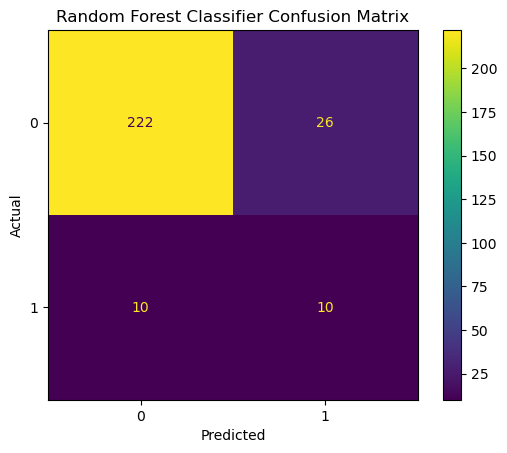

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix for Random Forest Classifier
# 0 = "non-premium" coffee beans
# 1 = "premium" coffee beans
cm = confusion_matrix(target_test, forest_prediction, labels= pipe.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = pipe.classes_)
disp.plot()
plt.title("Random Forest Classifier Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

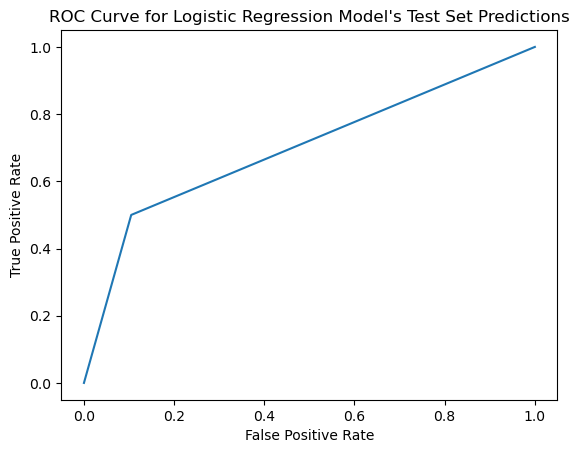

In [77]:
from sklearn.metrics import roc_curve
# ROC curve created using false positive rate and true positive rate of model's prediction versus actual
false_positive, true_positive, _ = roc_curve(target_test, forest_prediction)

plt.plot(false_positive, true_positive)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression Model's Test Set Predictions")
plt.show()

With the combination of the different metric scores and the confusion matrix, it shows that the random forest classifier model is not the best at predicting the target. Despite the accuracy being high, the precision score, recall score, and F1-score are all low. Only about half of the "premium" coffees in the test sets were accurately identified as true positives. 

## Step 5: Use Grid Search with 5-fold Cross Validation to Select Optimal Model and Hyperparameters

Since the random forest classifier did not have the best performance, I used a grid search with the 5-fold cross validation to determine if there was a better model choice for the data. I also added hyperparameters to the grid search to help fine tune the models and determine the best fit. Along with testing random forest classifier again, I also tested the logistic regression model and the deicision tree model. Once the grid search selected the best model and its respective hyperparameters, the accuracy, precision score, recall score, F1 score, confusion matrix, and ROC curve were used to evaluate the model. 

In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


Logistic_Regression = {"classifier" : [LogisticRegression(max_iter = 500, solver = "liblinear")], 
                       # Set to liblinear for high dimension data set
                       "classifier__penalty" : ["l1", "l2"], # Penatly regulates overfitting
                       "classifier__C" : np.logspace(0, 4, 10)}


Random_Forest = {"classifier" : [RandomForestClassifier()], 
                 "classifier__n_estimators" : [5, 10, 100, 1000], # Number of trees in forest
                 "classifier__max_features" : ["auto", "sqrt"], # Max # of featues considered for splitting a node
                "classifier__bootstrap": [True, False]} 

Decision_Tree = {"classifier" : [DecisionTreeClassifier()],
                 "classifier__max_depth": [3, 5, 7, 10, 15], # Depth of tree, more depth = more overfitting risk
                "classifier__max_features": ["auto", "sqrt", "log2"]} 
      

# Add Logistic Regression, Random Forest, and Decision parameter dictionaries to search empty space list 
search_space = [] # empty list
search_space.append(Logistic_Regression)
search_space.append(Random_Forest)
search_space.append(Decision_Tree)

print(search_space)

[{'classifier': [LogisticRegression(max_iter=500, solver='liblinear')], 'classifier__penalty': ['l1', 'l2'], 'classifier__C': array([1.00000000e+00, 2.78255940e+00, 7.74263683e+00, 2.15443469e+01,
       5.99484250e+01, 1.66810054e+02, 4.64158883e+02, 1.29154967e+03,
       3.59381366e+03, 1.00000000e+04])}, {'classifier': [RandomForestClassifier()], 'classifier__n_estimators': [5, 10, 100, 1000], 'classifier__max_features': ['auto', 'sqrt'], 'classifier__bootstrap': [True, False]}, {'classifier': [DecisionTreeClassifier()], 'classifier__max_depth': [3, 5, 7, 10, 15], 'classifier__max_features': ['auto', 'sqrt', 'log2']}]


In [81]:
from sklearn.model_selection import GridSearchCV

# Fit grid search with pipeline model, search space containing 3 classifier options, and 5-fold cross-validation 
gridsearch = GridSearchCV(pipe, search_space, cv = 5, verbose = 0).fit(features_train, target_train)

# Best Model with respective hyperparameters found in Grid Search
print("Best Model:", gridsearch.best_estimator_.get_params()["classifier"])

Best Model: RandomForestClassifier(bootstrap=False, max_features='sqrt')


In [82]:
# Best model found in grid search was Random Forest Classifier

# Create Random Forest model with hyperparameters set to optimal values based on Grid Search
forest_params = RandomForestClassifier(bootstrap=False, n_estimators=10)

# Create new pipeline with adjusted Random Forest model
pipe2 = Pipeline([("minmax", minmax_scale), ("classifier", forest_params)])

# Fit new pipeline with adjusted Random Forest model to training data sets 
pipe2.fit(features_train, target_train)

Pipeline(steps=[('minmax', MinMaxScaler()),
                ('classifier',
                 RandomForestClassifier(bootstrap=False, n_estimators=10))])

In [83]:
# Evaluation Metrics of Random Forest Model with Hyperparameter Presets
forest_prediction = pipe2.predict(features_test) 

print("Accuracy:", (accuracy_score(target_test, forest_prediction)*100), "%") 
print("Precision Score:", (precision_score(target_test, forest_prediction))*100, "%")
print("Recall Score:", (recall_score(target_test, forest_prediction))*100, "%")
print("F1-score:", (f1_score(target_test, forest_prediction))*100, "%")

Accuracy: 86.19402985074626 %
Precision Score: 25.71428571428571 %
Recall Score: 45.0 %
F1-score: 32.72727272727273 %


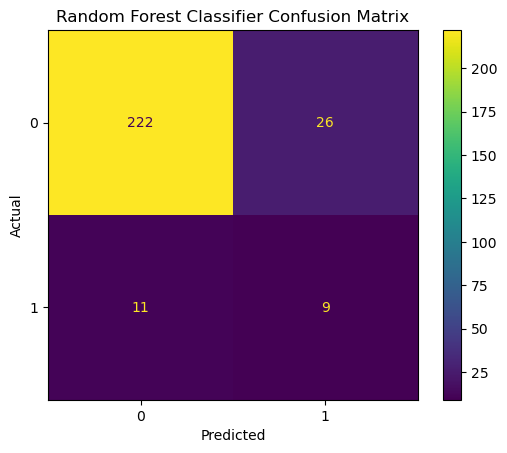

In [84]:
# Confusion Matrix for Updated Random Forest Classifier Model
cm = confusion_matrix(target_test, forest_prediction, labels= pipe2.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = pipe2.classes_)
disp.plot()
plt.title("Random Forest Classifier Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

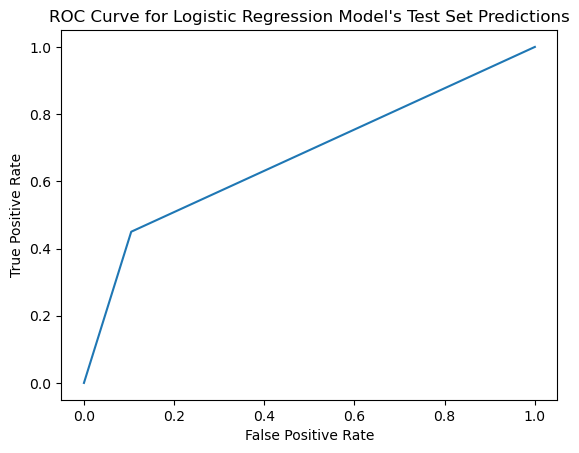

In [85]:
# ROC curve created using false positive rate and true positive rate of model's prediction versus actual 
false_positive, true_positive, _ = roc_curve(target_test, forest_prediction)

plt.plot(false_positive, true_positive)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression Model's Test Set Predictions")
plt.show()

Overall, the Random Forest Classifier model was found to be the best fit for the data set. Unfortunately, the model is not very good at predicting whether the coffee beans are "premium". This may be due to the imbalance of the target classes, but also the relationship between the feature variables and the target is not very strong. After tuning the Random Forest Classifier model using the hyperparameters chosen by the grid search, its evaluation metrics such as precision and recall decreased. This decrease may be accounting for any overfitting in the model. However, the model needs to be further fine tuned to increase these metrics again. 